# CS598 Project: Ring-of-Cliques Benchmark

This notebook studies whether a curvature-based clustering pipeline can recover planted communities on ring-of-cliques graphs better than Leiden baselines.

Pipeline:
1. Build ring-of-cliques graphs
2. Run Leiden-mod
3. Run Leiden-CPM (gamma = 0.01, 0.1, 0.5)
4. Run Ricci flow + manual threshold + connected components
5. Evaluate ARI / AMI / NMI / pairwise metrics
6. Save tables and figures for the paper

In [21]:
# If needed, uncomment and run:
# %pip install networkx python-igraph leidenalg scikit-learn pandas numpy matplotlib memory_profiler GraphRicciCurvature

In [16]:
import os
import time
import collections
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import igraph as ig
import leidenalg as la

from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    pair_confusion_matrix,
)

from GraphRicciCurvature.OllivierRicci import OllivierRicci
from GraphRicciCurvature.util import cut_graph_by_cutoff

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [17]:
import sys
print("Python executable:", sys.executable)

Python executable: /opt/anaconda3/envs/cs598proj/bin/python


In [3]:
def make_ring_of_cliques(n: int, m: int):
    """
    Create a ring of n cliques, each of size m.
    Consecutive cliques are connected by one bridge edge.
    
    Returns
    -------
    G : networkx.Graph
    y_true : list[int]
        Ground-truth community labels
    """
    if n < 3:
        raise ValueError("n must be at least 3.")
    if m < 2:
        raise ValueError("m must be at least 2.")

    G = nx.Graph()
    y_true = []

    for c in range(n):
        nodes = list(range(c * m, (c + 1) * m))
        G.add_nodes_from(nodes)

        for i in range(m):
            for j in range(i + 1, m):
                G.add_edge(nodes[i], nodes[j])

        y_true.extend([c] * m)

    for c in range(n):
        u = c * m
        v = ((c + 1) % n) * m
        G.add_edge(u, v)

    return G, y_true

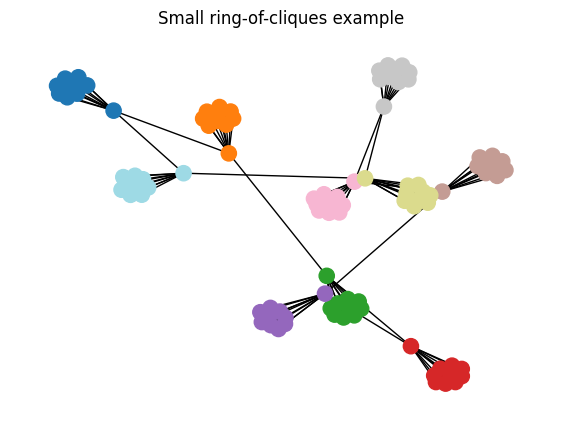

In [5]:
n = 10
m = 10

G_small, y_small = make_ring_of_cliques(n=n, m=m)

plt.figure(figsize=(7, 5))
pos = nx.spring_layout(G_small, seed=0)
nx.draw_networkx(
    G_small,
    pos=pos,
    with_labels=False,
    node_size=120,
    node_color=y_small,
    cmap=plt.cm.tab20
)
plt.title("Small ring-of-cliques example")
plt.axis("off")
plt.show()

In [6]:
def nx_to_igraph(G: nx.Graph) -> ig.Graph:
    n = G.number_of_nodes()
    if set(G.nodes()) != set(range(n)):
        raise ValueError("Expected nodes 0,1,...,n-1.")
    return ig.Graph(n=n, edges=list(G.edges()), directed=False)


def membership_to_labels(membership):
    return [int(x) for x in membership]


def communities_to_labels_from_node_sets(communities, n):
    labels = [-1] * n
    for cid, comm in enumerate(communities):
        for v in comm:
            labels[int(v)] = cid
    if any(x == -1 for x in labels):
        raise ValueError("Some nodes were not assigned.")
    return labels

In [7]:
def run_leiden_modularity(G_ig: ig.Graph, seed: int = 0):
    part = la.find_partition(
        G_ig,
        la.ModularityVertexPartition,
        n_iterations=-1,
        seed=seed,
    )
    return membership_to_labels(part.membership)


def run_leiden_cpm(G_ig: ig.Graph, gamma: float, seed: int = 0):
    part = la.find_partition(
        G_ig,
        la.CPMVertexPartition,
        resolution_parameter=gamma,
        n_iterations=-1,
        seed=seed,
    )
    return membership_to_labels(part.membership)

In [8]:
def run_curvature_manual_cut(
    G_nx,
    alpha=0.5,
    iterations=10,
    quantile=0.95,
):
    """
    Stable curvature pipeline:
    1. Run Ollivier-Ricci flow
    2. Threshold edges by final flow weight
    3. Remove edges above threshold
    4. Take connected components as communities

    Returns
    -------
    labels : list[int]
    cutoff : float
    orc : OllivierRicci object
    """
    orc = OllivierRicci(G_nx.copy(), alpha=alpha, method="Sinkhorn", verbose="ERROR")
    orc.compute_ricci_flow(iterations=iterations)

    n = G_nx.number_of_nodes()
    weights = np.array([orc.G[u][v]["weight"] for u, v in orc.G.edges()])
    cutoff = float(np.quantile(weights, quantile))

    G_cut = cut_graph_by_cutoff(orc.G, cutoff=cutoff, weight="weight")
    comps = list(nx.connected_components(G_cut))
    labels = communities_to_labels_from_node_sets(comps, n)

    return labels, cutoff, orc

In [9]:
def pairwise_metrics(y_true, y_pred):
    pcm = pair_confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = pcm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "pair_precision": precision,
        "pair_recall": recall,
        "fp_rate": fp_rate,
        "fn_rate": fn_rate,
        "pair_TN": int(tn),
        "pair_FP": int(fp),
        "pair_FN": int(fn),
        "pair_TP": int(tp),
    }


def cluster_size_distribution(labels):
    counter = collections.Counter(labels)
    return sorted(counter.values())


def evaluate_partition(y_true, y_pred):
    out = {
        "ARI": adjusted_rand_score(y_true, y_pred),
        "AMI": adjusted_mutual_info_score(y_true, y_pred),
        "NMI": normalized_mutual_info_score(y_true, y_pred),
        "num_clusters": len(set(y_pred)),
        "cluster_sizes": cluster_size_distribution(y_pred),
    }
    out.update(pairwise_metrics(y_true, y_pred))
    return out

In [10]:
def timed_run(fn, *args, **kwargs):
    start = time.perf_counter()
    output = fn(*args, **kwargs)
    runtime = time.perf_counter() - start
    return output, runtime

In [52]:
n = 1000
m = 7

G_nx, y_true = make_ring_of_cliques(n=n, m=m)
G_ig = nx_to_igraph(G_nx)

print("Nodes:", G_nx.number_of_nodes())
print("Edges:", G_nx.number_of_edges())
print("Ground-truth communities:", len(set(y_true)))

Nodes: 7000
Edges: 22000
Ground-truth communities: 1000


In [ ]:
# Leiden-mod
y_mod, t_mod = timed_run(run_leiden_modularity, G_ig, seed=0)
metrics_mod = evaluate_partition(y_true, y_mod)

# Leiden-CPM-0.01
y_cpm_001, t_cpm_001 = timed_run(run_leiden_cpm, G_ig, gamma=0.01, seed=0)
metrics_cpm_001 = evaluate_partition(y_true, y_cpm_001)

# Leiden-CPM-0.1
y_cpm_01, t_cpm_01 = timed_run(run_leiden_cpm, G_ig, gamma=0.1, seed=0)
metrics_cpm_01 = evaluate_partition(y_true, y_cpm_01)

# Leiden-CPM-0.5
y_cpm_05, t_cpm_05 = timed_run(run_leiden_cpm, G_ig, gamma=0.5, seed=0)
metrics_cpm_05 = evaluate_partition(y_true, y_cpm_05)

# Curvature
(curv_output, t_curv) = timed_run(
    run_curvature_manual_cut,
    G_nx,
    alpha=0.5,
    iterations=10,
    quantile=0.90
)
y_curv, cutoff_curv, orc = curv_output
metrics_curv = evaluate_partition(y_true, y_curv)

print("Curvature cutoff:", cutoff_curv)
print("Curvature num clusters:", len(set(y_curv)))

Curvature cutoff: 0.11418501463483978
Curvature num clusters: 1000


In [54]:
rows = [
    {"method": "Curvature", "runtime_sec": t_curv, **metrics_curv},
    {"method": "Leiden-mod", "runtime_sec": t_mod, **metrics_mod},
    {"method": "Leiden-CPM-0.01", "runtime_sec": t_cpm_001, **metrics_cpm_001},
    {"method": "Leiden-CPM-0.1", "runtime_sec": t_cpm_01, **metrics_cpm_01},
    {"method": "Leiden-CPM-0.5", "runtime_sec": t_cpm_05, **metrics_cpm_05},
]

df_one = pd.DataFrame(rows)

display_cols = [
    "method", "runtime_sec", "ARI", "AMI", "NMI",
    "pair_precision", "pair_recall", "fp_rate", "fn_rate", "num_clusters"
]
df_one[display_cols]

,method,runtime_sec,ARI,AMI,NMI,pair_precision,pair_recall,fp_rate,fn_rate,num_clusters
0,Curvature,65.195214,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,0.0,1000
1,Leiden-mod,0.120638,0.233858,0.671549,0.842734,0.133156,1.0,0.005586,0.0,154
2,Leiden-CPM-0.01,0.052809,0.563691,0.824505,0.936532,0.392979,1.0,0.001325,0.0,446
3,Leiden-CPM-0.1,0.046151,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,0.0,1000
4,Leiden-CPM-0.5,0.045302,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,0.0,1000


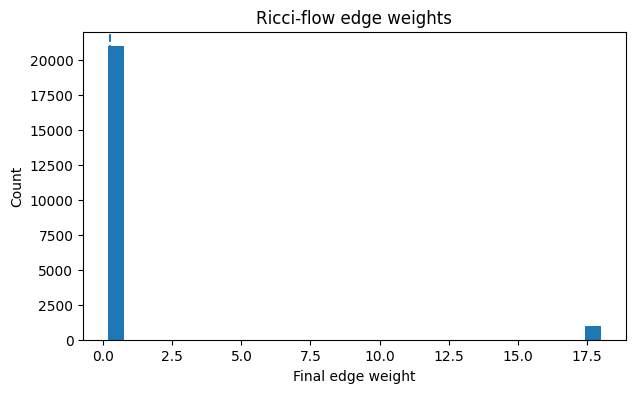

In [34]:
weights = [orc.G[u][v]["weight"] for u, v in orc.G.edges()]

plt.figure(figsize=(7, 4))
plt.hist(weights, bins=30)
plt.axvline(cutoff_curv, linestyle="--")
plt.title("Ricci-flow edge weights")
plt.xlabel("Final edge weight")
plt.ylabel("Count")
plt.show()

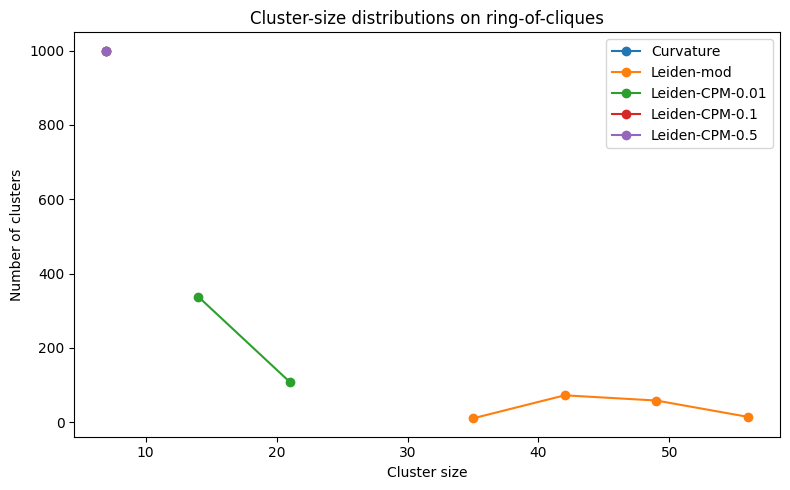

In [35]:
def plot_cluster_size_distributions(df, savepath=None):
    plt.figure(figsize=(8, 5))

    for _, row in df.iterrows():
        sizes = row["cluster_sizes"]
        counts = collections.Counter(sizes)
        xs = sorted(counts.keys())
        ys = [counts[x] for x in xs]
        plt.plot(xs, ys, marker="o", label=row["method"])

    plt.xlabel("Cluster size")
    plt.ylabel("Number of clusters")
    plt.title("Cluster-size distributions on ring-of-cliques")
    plt.legend()
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

plot_cluster_size_distributions(df_one)

In [60]:
def run_main_experiment(
    n=1000,
    m=7,
    seed=0,
    alpha=0.5,
    iterations=10,
    quantile=0.90,
):
    G_nx, y_true = make_ring_of_cliques(n=n, m=m)
    G_ig = nx_to_igraph(G_nx)

    # Curvature
    (curv_output, t_curv) = timed_run(
        run_curvature_manual_cut,
        G_nx,
        alpha=alpha,
        iterations=iterations,
        quantile=quantile
    )
    y_curv, cutoff_curv, orc = curv_output
    metrics_curv = evaluate_partition(y_true, y_curv)

    # Leiden-mod
    y_mod, t_mod = timed_run(run_leiden_modularity, G_ig, seed=seed)
    metrics_mod = evaluate_partition(y_true, y_mod)

    # Leiden-CPM-0.01
    y_cpm_001, t_cpm_001 = timed_run(run_leiden_cpm, G_ig, gamma=0.01, seed=seed)
    metrics_cpm_001 = evaluate_partition(y_true, y_cpm_001)

    # Leiden-CPM-0.1
    y_cpm_01, t_cpm_01 = timed_run(run_leiden_cpm, G_ig, gamma=0.1, seed=seed)
    metrics_cpm_01 = evaluate_partition(y_true, y_cpm_01)

    # Leiden-CPM-0.5
    y_cpm_05, t_cpm_05 = timed_run(run_leiden_cpm, G_ig, gamma=0.5, seed=seed)
    metrics_cpm_05 = evaluate_partition(y_true, y_cpm_05)

    df_results = pd.DataFrame([
        {"method": "Curvature", "runtime_sec": t_curv, "cutoff": cutoff_curv, **metrics_curv},
        {"method": "Leiden-mod", "runtime_sec": t_mod, "cutoff": np.nan, **metrics_mod},
        {"method": "Leiden-CPM-0.01", "runtime_sec": t_cpm_001, "cutoff": np.nan, **metrics_cpm_001},
        {"method": "Leiden-CPM-0.1", "runtime_sec": t_cpm_01, "cutoff": np.nan, **metrics_cpm_01},
        {"method": "Leiden-CPM-0.5", "runtime_sec": t_cpm_05, "cutoff": np.nan, **metrics_cpm_05},
        ])

    outputs = {
        "G_nx": G_nx,
        "y_true": y_true,
        "y_curv": y_curv,
        "y_mod": y_mod,
        "y_cpm_001": y_cpm_001,
        "y_cpm_01": y_cpm_01,
        "orc": orc,
        "cutoff_curv": cutoff_curv,
    }

    return df_results, outputs

In [67]:
df_results, outputs = run_main_experiment(
    n=1000,
    m=7,
    seed=0,
    alpha=0.5,
    iterations=10,
    quantile=0.90,
)

display_cols = [
    "method", "runtime_sec", "ARI", "AMI", "NMI",
    "pair_precision", "pair_recall", "fp_rate", "fn_rate",
    "num_clusters"
]
df_results[display_cols]

,method,runtime_sec,ARI,AMI,NMI,pair_precision,pair_recall,fp_rate,fn_rate,num_clusters
0,Curvature,69.646527,0.999857,0.999894,0.999970,1.000000,0.999714,0.000000,0.000286,1001
1,Leiden-mod,0.103399,0.233858,0.671549,0.842734,0.133156,1.000000,0.005586,0.000000,154
2,Leiden-CPM-0.01,0.049658,0.563691,0.824505,0.936532,0.392979,1.000000,0.001325,0.000000,446
3,Leiden-CPM-0.1,0.045377,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1000
4,Leiden-CPM-0.5,0.046247,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1000


n>m(m-1)+2.

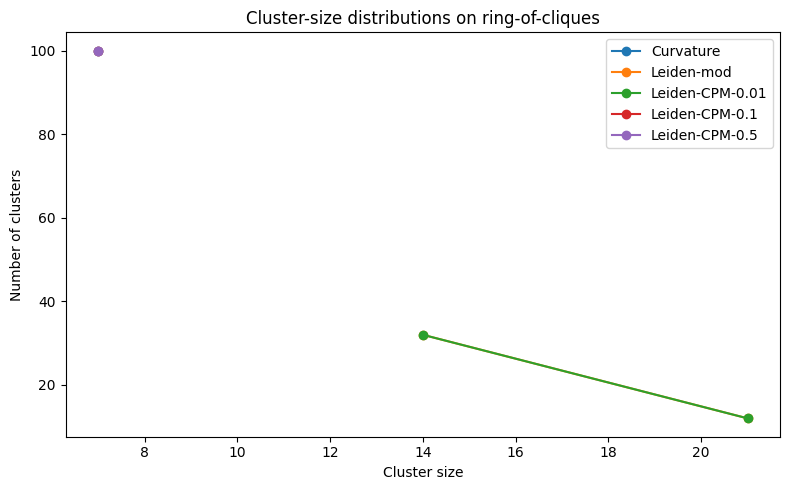

In [ ]:
plot_cluster_size_distributions(df_results, savepath="cluster_size_distribution_main.png")

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import os
import urllib.request
import tarfile
import zipfile

# ==========================================
# 1. 定义通用的数据集测试流水线
# ==========================================
def evaluate_real_dataset(dataset_name, G_nx, y_true):
    print(f"--- Running pipeline for {dataset_name} ---")
    print(f"Nodes: {G_nx.number_of_nodes()}, Edges: {G_nx.number_of_edges()}, Classes: {len(set(y_true))}")
    
    # 转换为 igraph
    G_ig = nx_to_igraph(G_nx)
    
    results = []
    
    # 1. Curvature (注意：真实网络建议 quantile 稍微调低，如 0.85 或 0.90)
    print("Running Curvature...")
    try:
        (curv_output, t_curv) = timed_run(
            run_curvature_manual_cut, G_nx, alpha=0.5, iterations=10, quantile=0.85
        )
        y_curv, cutoff_curv, _ = curv_output
        results.append({"method": "Curvature", "runtime_sec": t_curv, "cutoff": cutoff_curv, **evaluate_partition(y_true, y_curv)})
    except Exception as e:
        print(f"Curvature failed: {e}")
    
    # 2. Leiden-mod
    print("Running Leiden-mod...")
    y_mod, t_mod = timed_run(run_leiden_modularity, G_ig, seed=0)
    results.append({"method": "Leiden-mod", "runtime_sec": t_mod, "cutoff": np.nan, **evaluate_partition(y_true, y_mod)})
    
    # 3. Leiden-CPM
    for gamma in [0.01, 0.1, 0.5]:
        print(f"Running Leiden-CPM-{gamma}...")
        y_cpm, t_cpm = timed_run(run_leiden_cpm, G_ig, gamma=gamma, seed=0)
        results.append({"method": f"Leiden-CPM-{gamma}", "runtime_sec": t_cpm, "cutoff": np.nan, **evaluate_partition(y_true, y_cpm)})
    
    df = pd.DataFrame(results)
    df.insert(0, 'dataset', dataset_name)
    return df

# ==========================================
# 2. 加载与预处理: Political Blogs (修复 403 错误 与 边重复报错)
# ==========================================
def load_polblogs():
    import urllib.request
    import zipfile
    import os
    
    url = "http://www-personal.umich.edu/~mejn/netdata/polblogs.zip"
    if not os.path.exists("polblogs.gml"):
        print("Downloading polblogs...")
        # 伪装成浏览器来绕过 403 限制
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open("polblogs.zip", 'wb') as out_file:
            out_file.write(response.read())
            
        with zipfile.ZipFile("polblogs.zip", 'r') as zip_ref:
            zip_ref.extractall()
            
    # ---------------- 核心修复部分 ----------------
    # 读取原始 GML 文件，并在 graph 定义后强行加上 "multigraph 1"
    with open("polblogs.gml", "r", encoding="utf-8") as f:
        lines = f.readlines()
        
    with open("polblogs_fixed.gml", "w", encoding="utf-8") as f:
        for line in lines:
            f.write(line)
            if line.strip() == "graph [":
                f.write("    multigraph 1\n") # 声明为多重图以绕过重复边报错
    # ----------------------------------------------

    # 加载修复后的 GML 文件 (此时 G_raw 是 MultiDiGraph)
    print("Parsing fixed GML file...")
    G_raw = nx.read_gml("polblogs_fixed.gml")
    
    # 转换为无向简单图，这会自动去除有向性并把多重边合并为单条边
    G = nx.Graph(G_raw) 
    
    # 提取最大连通子图 (LCC)
    lcc = max(nx.connected_components(G), key=len)
    G = G.subgraph(lcc).copy()
    
    # 提取真实的政治倾向标签 (0=左翼, 1=右翼)
    y_true = [G.nodes[n]['value'] for n in G.nodes()]
    
    # 重建节点索引 (0 to N-1)
    G = nx.convert_node_labels_to_integers(G)
    
    return G, y_true
# ==========================================
# 3. 加载与预处理: Cora Citation Network
# ==========================================
def load_cora():
    # 数据集来源: LINQS
    url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
    if not os.path.exists("cora"):
        print("Downloading Cora...")
        urllib.request.urlretrieve(url, "cora.tgz")
        with tarfile.open("cora.tgz", "r:gz") as tar:
            tar.extractall()
            
    # 读取节点信息和真实类别 (7种机器学习子领域)
    # 格式: <paper_id> <word_attributes>+ <class_label>
    node_data = pd.read_csv("cora/cora.content", sep='\t', header=None, low_memory=False)
    node_ids = node_data.iloc[:, 0].astype(str).values
    labels = node_data.iloc[:, -1].values
    
    # 将字符串标签映射为整数 (0 到 6)
    label_map = {label: i for i, label in enumerate(np.unique(labels))}
    id_to_label = {node_ids[i]: label_map[labels[i]] for i in range(len(node_ids))}
    
    # 读取边信息 (引用关系)
    edges_data = pd.read_csv("cora/cora.cites", sep='\t', header=None, dtype=str)
    
    G = nx.Graph()
    G.add_edges_from(edges_data.values)
    
    # 提取最大连通子图
    lcc = max(nx.connected_components(G), key=len)
    G = G.subgraph(lcc).copy()
    
    # 提取对齐的 Ground Truth 标签
    y_true = [id_to_label[n] for n in G.nodes()]
    
    # 重建节点索引
    G = nx.convert_node_labels_to_integers(G)
    
    return G, y_true

# ==========================================
# 4. 运行主实验
# ==========================================
all_results = []

# 测试 Polblogs (约 1222 节点，二分类)
G_polblogs, y_polblogs = load_polblogs()
df_polblogs = evaluate_real_dataset("Polblogs", G_polblogs, y_polblogs)
all_results.append(df_polblogs)

# 测试 Cora (约 2485 节点(最大连通块)，七分类)
G_cora, y_cora = load_cora()
df_cora = evaluate_real_dataset("Cora", G_cora, y_cora)
all_results.append(df_cora)

# 汇总并显示结果
df_final = pd.concat(all_results, ignore_index=True)

display_cols = [
    "dataset", "method", "runtime_sec", "ARI", "AMI", "NMI",
    "pair_precision", "pair_recall", "num_clusters", "cutoff"
]

print("\n--- Final Benchmark Results ---")
display(df_final[display_cols])

Parsing fixed GML file...
--- Running pipeline for Polblogs ---
Nodes: 1222, Edges: 16717, Classes: 2
Running Curvature...
Running Leiden-mod...
Running Leiden-CPM-0.01...
Running Leiden-CPM-0.1...
Running Leiden-CPM-0.5...
--- Running pipeline for Cora ---
Nodes: 2485, Edges: 5069, Classes: 7
Running Curvature...
Running Leiden-mod...
Running Leiden-CPM-0.01...
Running Leiden-CPM-0.1...
Running Leiden-CPM-0.5...

--- Final Benchmark Results ---


,dataset,method,runtime_sec,ARI,AMI,NMI,pair_precision,pair_recall,num_clusters,cutoff
0,Polblogs,Curvature,37.110493,0.602462,0.429419,0.451296,0.916621,0.663018,83,1.063875
1,Polblogs,Leiden-mod,0.072020,0.765450,0.629667,0.632005,0.922950,0.835370,11,NaN
2,Polblogs,Leiden-CPM-0.01,0.044596,0.421203,0.258464,0.336963,0.947140,0.446347,338,NaN
3,Polblogs,Leiden-CPM-0.1,0.076236,0.091926,0.149147,0.220950,0.965370,0.095426,420,NaN
4,Polblogs,Leiden-CPM-0.5,0.084896,0.010624,0.083603,0.187884,0.972844,0.010939,696,NaN
5,Cora,Curvature,7.581199,-0.006756,0.024718,0.045207,0.174666,0.918055,20,2.414972
6,Cora,Leiden-mod,0.102573,0.265417,0.466911,0.475038,0.674734,0.217524,30,NaN
7,Cora,Leiden-CPM-0.01,0.075098,0.078293,0.392407,0.425455,0.769731,0.053144,136,NaN
8,Cora,Leiden-CPM-0.1,0.107916,0.016011,0.284171,0.396249,0.806199,0.010351,510,NaN
9,Cora,Leiden-CPM-0.5,0.048219,0.004195,0.147316,0.388249,0.861557,0.002647,1363,NaN


Calculating layout for Political Blogs Network (this may take 10-20 seconds)...


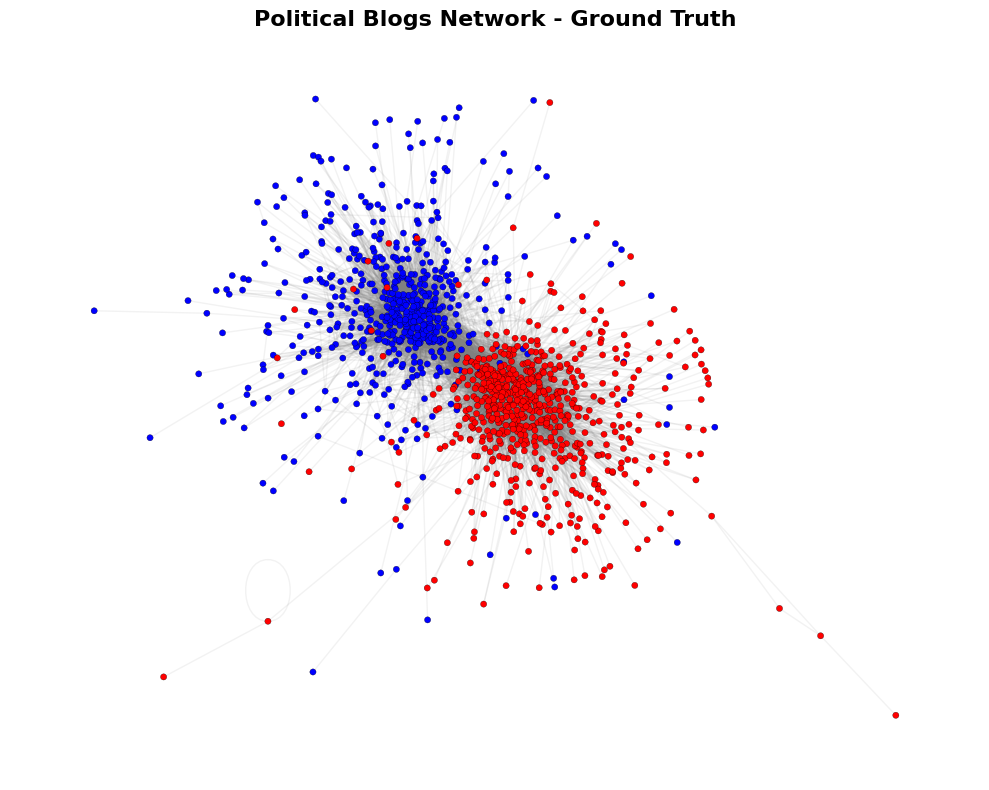

Calculating layout for Cora Citation Network (this may take 10-20 seconds)...


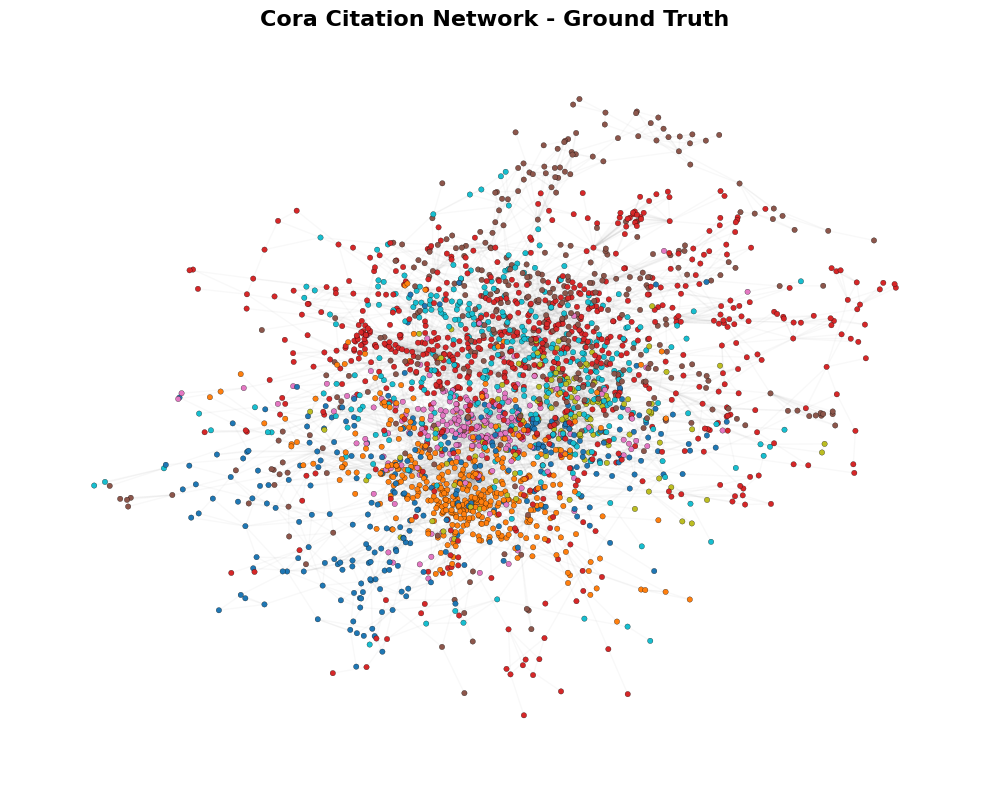

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_large_real_network(G, labels, title, cmap_name="bwr", node_size=15, alpha=0.15):
    """
    绘制大型真实网络，优化了布局、节点大小和边缘透明度，以防止“面条效应”
    """
    print(f"Calculating layout for {title} (this may take 10-20 seconds)...")
    # 使用 spring_layout，对于 1000-2500 节点的图大约需要十几秒
    # k 参数控制节点间的最佳距离，数值越小越紧凑
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)
    
    plt.figure(figsize=(10, 8))
    
    # 绘制边 (降低透明度，使其作为背景)
    nx.draw_networkx_edges(G, pos, alpha=alpha, edge_color="gray")
    
    # 绘制节点 (根据真实的 Ground Truth 标签染色)
    nodes = nx.draw_networkx_nodes(
        G, pos, 
        node_color=labels, 
        node_size=node_size, 
        cmap=plt.get_cmap(cmap_name),
        linewidths=0.2,
        edgecolors="black" # 给节点加一层极细的黑边增加立体感
    )
    
    plt.title(f"{title} - Ground Truth", fontsize=16, fontweight='bold')
    plt.axis("off")
    
    # 根据数据集添加图例
    if "Polblogs" in title:
        # Polblogs 只有 0 和 1
        plt.legend(handles=nodes.legend_elements()[0], labels=['Left (0)', 'Right (1)'], loc="best")
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 绘制 Polblogs (使用红蓝配色，代表政治两极)
# ==========================================
# 假设 G_polblogs 和 y_polblogs 已经在内存中
plot_large_real_network(
    G=G_polblogs, 
    labels=y_polblogs, 
    title="Political Blogs Network", 
    cmap_name="bwr", # Blue-White-Red 很适合左右翼两极分化
    node_size=20, 
    alpha=0.1
)

# ==========================================
# 绘制 Cora (使用 Tab10 离散调色板，代表 7 个子领域)
# ==========================================
# 假设 G_cora 和 y_cora 已经在内存中
plot_large_real_network(
    G=G_cora, 
    labels=y_cora, 
    title="Cora Citation Network", 
    cmap_name="tab10", # 适合多分类
    node_size=15, 
    alpha=0.05 # Cora 边比较多且杂，透明度调得更低
)

In [69]:
# =========================================================
# Additional benchmark: planted-partition SBM
# N=5000, q=100, community_size=50, c_in=10, c_out=2
# =========================================================

import numpy as np
import pandas as pd
import networkx as nx

# -----------------------------
# Parameters
# -----------------------------
seed = 0

N = 5000
q = 100
community_size = 50

c_in = 10
c_out = 2

assert N == q * community_size

p_in = c_in / (community_size - 1)
p_out = c_out / (N - community_size)

print("Synthetic planted-partition SBM")
print(f"N = {N}")
print(f"q = {q}")
print(f"community_size = {community_size}")
print(f"c_in = {c_in}, c_out = {c_out}")
print(f"p_in = {p_in:.6f}")
print(f"p_out = {p_out:.8f}")

# -----------------------------
# Generate SBM
# -----------------------------
sizes = [community_size] * q

probs = [
    [p_in if i == j else p_out for j in range(q)]
    for i in range(q)
]

G_sbm = nx.stochastic_block_model(
    sizes=sizes,
    p=probs,
    seed=seed,
    sparse=True
)

G_sbm = nx.convert_node_labels_to_integers(G_sbm)
G_sbm.remove_edges_from(nx.selfloop_edges(G_sbm))

y_true_sbm = np.repeat(np.arange(q), community_size)

print("\nGenerated graph:")
print("Nodes:", G_sbm.number_of_nodes())
print("Edges:", G_sbm.number_of_edges())
print("Connected components:", nx.number_connected_components(G_sbm))
print("Ground-truth communities:", len(set(y_true_sbm)))

G_ig_sbm = nx_to_igraph(G_sbm)

# -----------------------------
# Run five methods
# -----------------------------
results_sbm = []

# 1. Curvature
print("\nRunning Curvature...")

curv_output, t_curv = timed_run(
    run_curvature_manual_cut,
    G_sbm,
    alpha=0.5,
    iterations=10,
    quantile=0.90
)

y_curv, cutoff_curv, orc_curv = curv_output

metrics_curv = evaluate_partition(y_true_sbm, y_curv)

print("Curvature cutoff:", cutoff_curv)
print("Curvature num clusters:", len(set(y_curv)))

results_sbm.append({
    "method": "Curvature",
    "runtime_sec": t_curv,
    "cutoff": cutoff_curv,
    **metrics_curv
})

# 2. Leiden modularity
print("\nRunning Leiden-mod...")

y_mod, t_mod = timed_run(
    run_leiden_modularity,
    G_ig_sbm,
    seed=seed
)

metrics_mod = evaluate_partition(y_true_sbm, y_mod)

print("Leiden-mod num clusters:", len(set(y_mod)))

results_sbm.append({
    "method": "Leiden-mod",
    "runtime_sec": t_mod,
    "cutoff": np.nan,
    **metrics_mod
})

# 3-5. Leiden CPM
for gamma in [0.01, 0.1, 0.5]:
    print(f"\nRunning Leiden-CPM-{gamma}...")

    y_cpm, t_cpm = timed_run(
        run_leiden_cpm,
        G_ig_sbm,
        gamma=gamma,
        seed=seed
    )

    metrics_cpm = evaluate_partition(y_true_sbm, y_cpm)

    print(f"Leiden-CPM-{gamma} num clusters:", len(set(y_cpm)))

    results_sbm.append({
        "method": f"Leiden-CPM-{gamma}",
        "runtime_sec": t_cpm,
        "cutoff": np.nan,
        **metrics_cpm
    })

# -----------------------------
# Results table
# -----------------------------
df_sbm = pd.DataFrame(results_sbm)

preferred_cols = [
    "method",
    "runtime_sec",
    "cutoff",
    "ARI",
    "AMI",
    "NMI",
    "pair_precision",
    "pair_recall",
    "fp_rate",
    "fn_rate",
    "num_clusters",
]

df_sbm = df_sbm[[c for c in preferred_cols if c in df_sbm.columns]]

display(df_sbm)

df_sbm.to_csv("sbm_N5000_q100_m50_cin10_cout2_results.csv", index=False)
print("\nSaved to sbm_N5000_q100_m50_cin10_cout2_results.csv")

Synthetic planted-partition SBM
N = 5000
q = 100
community_size = 50
c_in = 10, c_out = 2
p_in = 0.204082
p_out = 0.00040404

Generated graph:
Nodes: 5000
Edges: 30096
Connected components: 1
Ground-truth communities: 100

Running Curvature...
Curvature cutoff: 3.9755224012169057
Curvature num clusters: 1

Running Leiden-mod...
Leiden-mod num clusters: 99

Running Leiden-CPM-0.01...
Leiden-CPM-0.01 num clusters: 100

Running Leiden-CPM-0.1...
Leiden-CPM-0.1 num clusters: 178

Running Leiden-CPM-0.5...
Leiden-CPM-0.5 num clusters: 1858


,method,runtime_sec,cutoff,ARI,AMI,NMI,pair_precision,pair_recall,fp_rate,fn_rate,num_clusters
0,Curvature,59.315628,3.975522,0.000000,0.000000,0.000000,0.009802,1.000000,1.000000,0.000000,1
1,Leiden-mod,0.123193,NaN,0.989798,0.998080,0.998493,0.980000,1.000000,0.000202,0.000000,99
2,Leiden-CPM-0.01,0.107790,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,100
3,Leiden-CPM-0.1,0.464761,NaN,0.964193,0.978560,0.983661,0.999361,0.932049,0.000006,0.067951,178
4,Leiden-CPM-0.5,0.329234,NaN,0.077760,0.375799,0.742674,0.911679,0.041037,0.000039,0.958963,1858



Saved to sbm_N5000_q100_m50_cin10_cout2_results.csv


In [71]:
# =========================================================
# Real-world benchmark: SNAP ca-GrQc collaboration network
# Nodes: authors, edges: co-authorships
# No clean ground truth, so we report runtime, modularity,
# number of clusters, and cluster-size summaries.
# =========================================================

import os
import gzip
import urllib.request
import numpy as np
import pandas as pd
import networkx as nx

# -----------------------------
# Helper functions
# -----------------------------
def load_snap_ca_grqc(path="ca-GrQc.txt.gz"):
    """
    Download and load SNAP ca-GrQc as an undirected simple graph.
    """
    url = "https://snap.stanford.edu/data/ca-GrQc.txt.gz"

    if not os.path.exists(path):
        print(f"Downloading {url} ...")
        urllib.request.urlretrieve(url, path)

    edges = []
    with gzip.open(path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue
            u, v = map(int, line.strip().split())
            if u != v:
                edges.append((u, v))

    G = nx.Graph()
    G.add_edges_from(edges)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = nx.convert_node_labels_to_integers(G)

    return G


def labels_from_components(G):
    labels = np.empty(G.number_of_nodes(), dtype=int)
    for cid, comp in enumerate(nx.connected_components(G)):
        for node in comp:
            labels[node] = cid
    return labels


def cluster_size_summary(labels):
    sizes = pd.Series(labels).value_counts().sort_values(ascending=False)
    return {
        "num_clusters": int(len(sizes)),
        "largest_cluster": int(sizes.iloc[0]),
        "median_cluster": float(sizes.median()),
        "num_singletons": int((sizes == 1).sum()),
        "top5_sizes": list(map(int, sizes.head(5).values)),
    }


def modularity_nx(G, labels):
    communities = {}
    for node, lab in enumerate(labels):
        communities.setdefault(int(lab), set()).add(node)

    comm_list = list(communities.values())

    # NetworkX modularity can fail on empty graphs; guard just in case.
    if G.number_of_edges() == 0:
        return np.nan

    return nx.algorithms.community.quality.modularity(G, comm_list)


def summarize_real_result(method, runtime, G, labels, cutoff=np.nan):
    s = cluster_size_summary(labels)
    return {
        "method": method,
        "runtime_sec": runtime,
        "cutoff": cutoff,
        "modularity": modularity_nx(G, labels),
        **s,
    }


# -----------------------------
# Load graph
# -----------------------------
G_real = load_snap_ca_grqc()

# Use largest connected component for cleaner comparison
largest_cc = max(nx.connected_components(G_real), key=len)
G_real_lcc = G_real.subgraph(largest_cc).copy()
G_real_lcc = nx.convert_node_labels_to_integers(G_real_lcc)

print("SNAP ca-GrQc collaboration network")
print("Original graph:")
print("  Nodes:", G_real.number_of_nodes())
print("  Edges:", G_real.number_of_edges())
print("  Connected components:", nx.number_connected_components(G_real))
print()
print("Largest connected component:")
print("  Nodes:", G_real_lcc.number_of_nodes())
print("  Edges:", G_real_lcc.number_of_edges())
print("  Connected components:", nx.number_connected_components(G_real_lcc))

G_ig_real = nx_to_igraph(G_real_lcc)

# -----------------------------
# Run methods
# -----------------------------
real_results = []

# 1. Curvature
print("\nRunning Curvature on ca-GrQc LCC...")

curv_output, t_curv = timed_run(
    run_curvature_manual_cut,
    G_real_lcc,
    alpha=0.5,
    iterations=10,
    quantile=0.90
)

y_curv, cutoff_curv, orc_real = curv_output

print("Curvature cutoff:", cutoff_curv)
print("Curvature num clusters:", len(set(y_curv)))

real_results.append(
    summarize_real_result(
        method="Curvature",
        runtime=t_curv,
        G=G_real_lcc,
        labels=y_curv,
        cutoff=cutoff_curv
    )
)

# 2. Leiden modularity
print("\nRunning Leiden-modularity on ca-GrQc LCC...")

y_mod, t_mod = timed_run(
    run_leiden_modularity,
    G_ig_real,
    seed=0
)

print("Leiden-mod num clusters:", len(set(y_mod)))

real_results.append(
    summarize_real_result(
        method="Leiden-mod",
        runtime=t_mod,
        G=G_real_lcc,
        labels=y_mod
    )
)

# 3-5. Leiden CPM
for gamma in [0.01, 0.1, 0.5]:
    print(f"\nRunning Leiden-CPM-{gamma} on ca-GrQc LCC...")

    y_cpm, t_cpm = timed_run(
        run_leiden_cpm,
        G_ig_real,
        gamma=gamma,
        seed=0
    )

    print(f"Leiden-CPM-{gamma} num clusters:", len(set(y_cpm)))

    real_results.append(
        summarize_real_result(
            method=f"Leiden-CPM-{gamma}",
            runtime=t_cpm,
            G=G_real_lcc,
            labels=y_cpm
        )
    )

# -----------------------------
# Results table
# -----------------------------
df_real = pd.DataFrame(real_results)

preferred_cols = [
    "method",
    "runtime_sec",
    "cutoff",
    "modularity",
    "num_clusters",
    "largest_cluster",
    "median_cluster",
    "num_singletons",
    "top5_sizes",
]

df_real = df_real[[c for c in preferred_cols if c in df_real.columns]]

display(df_real)

df_real.to_csv("ca_grqc_real_network_results.csv", index=False)
print("\nSaved to ca_grqc_real_network_results.csv")

SNAP ca-GrQc collaboration network
Original graph:
  Nodes: 5241
  Edges: 14484
  Connected components: 354

Largest connected component:
  Nodes: 4158
  Edges: 13422
  Connected components: 1

Running Curvature on ca-GrQc LCC...
Curvature cutoff: 3.450041928184414
Curvature num clusters: 57

Running Leiden-modularity on ca-GrQc LCC...
Leiden-mod num clusters: 42

Running Leiden-CPM-0.01 on ca-GrQc LCC...
Leiden-CPM-0.01 num clusters: 212

Running Leiden-CPM-0.1 on ca-GrQc LCC...
Leiden-CPM-0.1 num clusters: 755

Running Leiden-CPM-0.5 on ca-GrQc LCC...
Leiden-CPM-0.5 num clusters: 1908


,method,runtime_sec,cutoff,modularity,num_clusters,largest_cluster,median_cluster,num_singletons,top5_sizes
0,Curvature,30.768868,3.450042,0.092564,57,3772,6.0,0,"[3772, 32, 20, 16, 16]"
1,Leiden-mod,0.137300,NaN,0.853792,42,287,86.0,0,"[287, 256, 223, 214, 205]"
2,Leiden-CPM-0.01,0.155743,NaN,0.819617,212,134,17.0,15,"[134, 85, 69, 66, 62]"
3,Leiden-CPM-0.1,0.145041,NaN,0.713338,755,53,5.0,134,"[53, 43, 35, 24, 24]"
4,Leiden-CPM-0.5,0.082264,NaN,0.555863,1908,46,2.0,932,"[46, 43, 35, 24, 24]"



Saved to ca_grqc_real_network_results.csv


## EC-SBM Benchmark

Evaluate clustering methods on EC-SBM generated graphs with provenance tracking.

**Input files (any EC-SBM output directory):**
- `edge.csv` — `source,target` edge list
- `com.csv` — `node_id,cluster_id` ground-truth communities *(clustered nodes only; outlier nodes are absent)*
- `sources.json` — maps each generation stage to a 1-based inclusive row range in `edge.csv`

**Provenance analysis** cross-references `sources.json` stage assignments with `com.csv` cluster labels to classify each stage's edges as intra-cluster, inter-cluster, or involving outlier nodes.

**Evaluation** is restricted to clustered nodes (those present in `com.csv`); outlier nodes (label = -1) are excluded from all metrics.

In [18]:
import json, os, time, collections
import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import leidenalg as la
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    normalized_mutual_info_score, pair_confusion_matrix,
)
from GraphRicciCurvature.OllivierRicci import OllivierRicci
from GraphRicciCurvature.util import cut_graph_by_cutoff

# ── Clustering methods ─────────────────────────────────────────────────────────

def nx_to_igraph(G):
    n = G.number_of_nodes()
    if set(G.nodes()) != set(range(n)):
        raise ValueError("Nodes must be 0..n-1. Use build_graph_from_ecsbm first.")
    return ig.Graph(n=n, edges=list(G.edges()), directed=False)

def timed_run(fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    return out, time.perf_counter() - t0

def run_leiden_modularity(G_ig, seed=0):
    part = la.find_partition(G_ig, la.ModularityVertexPartition, n_iterations=-1, seed=seed)
    return [int(x) for x in part.membership]

def run_leiden_cpm(G_ig, gamma, seed=0):
    part = la.find_partition(G_ig, la.CPMVertexPartition,
                             resolution_parameter=gamma, n_iterations=-1, seed=seed)
    return [int(x) for x in part.membership]

def run_curvature_manual_cut(G_nx, alpha=0.5, iterations=10, quantile=0.90):
    orc = OllivierRicci(G_nx.copy(), alpha=alpha, method="Sinkhorn", verbose="ERROR")
    orc.compute_ricci_flow(iterations=iterations)
    weights = np.array([orc.G[u][v]["weight"] for u, v in orc.G.edges()])
    cutoff  = float(np.quantile(weights, quantile))
    G_cut   = cut_graph_by_cutoff(orc.G, cutoff=cutoff, weight="weight")
    comps   = list(nx.connected_components(G_cut))
    n       = G_nx.number_of_nodes()
    labels  = [-1] * n
    for cid, comp in enumerate(comps):
        for v in comp:
            labels[int(v)] = cid
    return labels, cutoff, orc

# ── EC-SBM data loading ────────────────────────────────────────────────────────

def load_ecsbm_data(base_dir):
    """Load edge.csv, com.csv, sources.json. Returns (edges_df, node_cluster, sources)."""
    edges_df = pd.read_csv(os.path.join(base_dir, "edge.csv"))
    com_df   = pd.read_csv(os.path.join(base_dir, "com.csv"))
    with open(os.path.join(base_dir, "sources.json")) as f:
        sources = json.load(f)
    node_cluster = dict(zip(com_df["node_id"], com_df["cluster_id"]))
    # sources.json uses 1-based inclusive row indices into edge.csv data rows
    stage_col = [""] * len(edges_df)
    for stage, (start, end) in sources.items():
        for i in range(start - 1, end):
            stage_col[i] = stage
    edges_df["stage"] = stage_col
    return edges_df, node_cluster, sources

def build_graph_from_ecsbm(edges_df):
    """Undirected NetworkX graph with nodes relabeled 0..N-1. Returns (G, node_map)."""
    G = nx.Graph()
    G.add_edges_from(zip(edges_df["source"], edges_df["target"]))
    nodes_sorted = sorted(G.nodes())
    node_map = {n: i for i, n in enumerate(nodes_sorted)}
    return nx.relabel_nodes(G, node_map), node_map

# ── Core Recovery Score ────────────────────────────────────────────────────────

def extract_cluster_cores(edges_df, node_cluster,
                          core_stages=("clustered_kec_clique",)):
    """
    Core nodes = nodes incident to edges from core_stages (the k-edge-connected cliques).
    Returns dict: cluster_id -> frozenset of original node IDs.
    """
    mask  = edges_df["stage"].isin(core_stages)
    cores = {}
    for _, row in edges_df[mask].iterrows():
        for node in (row["source"], row["target"]):
            cl = node_cluster.get(node)
            if cl is not None:
                cores.setdefault(cl, set()).add(node)
    return {cl: frozenset(s) for cl, s in cores.items()}

def compute_core_recovery(cluster_cores, y_pred, node_map):
    """
    For each true cluster's core K_c:
      recovery(c)       = fraction of K_c nodes in the dominant predicted cluster
      contaminated(c)   = another core also appears in that predicted cluster
      cleanly_recovered = recovery == 1.0 AND not contaminated
    Returns (per_core_df, summary_dict).
    """
    inv_map      = {v: k for k, v in node_map.items()}
    node_to_pred = {inv_map[i]: y_pred[i] for i in range(len(y_pred))}

    rows = []
    for cl, core_nodes in cluster_cores.items():
        pred_labels = [node_to_pred[n] for n in core_nodes if n in node_to_pred]
        if not pred_labels:
            continue
        counter        = collections.Counter(pred_labels)
        p_star, n_in_p = counter.most_common(1)[0]
        recovery       = n_in_p / len(core_nodes)
        contaminated_by = {
            other_cl for other_cl, other_core in cluster_cores.items()
            if other_cl != cl and any(node_to_pred.get(n) == p_star for n in other_core)
        }
        rows.append({
            "true_cluster":      cl,
            "core_size":         len(core_nodes),
            "dominant_pred":     p_star,
            "nodes_in_dominant": n_in_p,
            "recovery":          round(recovery, 4),
            "fully_recovered":   recovery == 1.0,
            "contaminated":      len(contaminated_by) > 0,
            "n_contaminants":    len(contaminated_by),
            "cleanly_recovered": recovery == 1.0 and len(contaminated_by) == 0,
        })

    df = pd.DataFrame(rows).sort_values("true_cluster").reset_index(drop=True)
    summary = {
        "n_cores":             len(df),
        "full_recovery_rate":  round(df["fully_recovered"].mean(), 4),
        "clean_recovery_rate": round(df["cleanly_recovered"].mean(), 4),
        "mean_recovery":       round(df["recovery"].mean(), 4),
        "n_split":             int((~df["fully_recovered"]).sum()),
        "n_merged":            int(df["contaminated"].sum()),
    }
    return df, summary

print("EC-SBM utilities ready.")

EC-SBM utilities ready.


In [19]:
# =============================================================
# EC-SBM Core Recovery Benchmark
# Change EC_SBM_DIR to run on any folder with edge.csv / com.csv / sources.json
# =============================================================

EC_SBM_DIR = "ec-sbm-main/examples/output/ec-sbm-v2"

# ── 1. Load ───────────────────────────────────────────────────
edges_df, node_cluster, sources = load_ecsbm_data(EC_SBM_DIR)
G, node_map = build_graph_from_ecsbm(edges_df)
inv_map = {v: k for k, v in node_map.items()}

n_nodes     = G.number_of_nodes()
n_clustered = sum(1 for i in range(n_nodes) if node_cluster.get(inv_map[i]) is not None)
print(f"Graph  : {n_nodes} nodes ({n_clustered} clustered, {n_nodes - n_clustered} outlier)"
      f", {G.number_of_edges()} edges")
print(f"Stages : {list(sources.keys())}")

# ── 2. Extract cores (k-edge-connected cliques) ───────────────
cluster_cores = extract_cluster_cores(edges_df, node_cluster,
                                      core_stages=("clustered_kec_clique",))
core_sizes = [len(v) for v in cluster_cores.values()]
print(f"Cores  : {len(cluster_cores)} clusters, "
      f"size min/mean/max = {min(core_sizes)}/{sum(core_sizes)/len(core_sizes):.1f}/{max(core_sizes)}")

# ── 3. Run 5 methods ──────────────────────────────────────────
G_ig = nx_to_igraph(G)

y_mod,     t_mod     = timed_run(run_leiden_modularity, G_ig, seed=0)
y_cpm_001, t_cpm_001 = timed_run(run_leiden_cpm, G_ig, gamma=0.01, seed=0)
y_cpm_01,  t_cpm_01  = timed_run(run_leiden_cpm, G_ig, gamma=0.1,  seed=0)
y_cpm_05,  t_cpm_05  = timed_run(run_leiden_cpm, G_ig, gamma=0.5,  seed=0)

print("Running Curvature (may take ~1–2 min)...")
(y_curv, cutoff, _), t_curv = timed_run(
    run_curvature_manual_cut, G, alpha=0.5, iterations=10, quantile=0.90
)

methods = [
    ("Leiden-mod",      y_mod,     t_mod),
    ("Leiden-CPM-0.01", y_cpm_001, t_cpm_001),
    ("Leiden-CPM-0.1",  y_cpm_01,  t_cpm_01),
    ("Leiden-CPM-0.5",  y_cpm_05,  t_cpm_05),
    ("Curvature",       y_curv,    t_curv),
]

# ── 4. Core Recovery Score ────────────────────────────────────
rows = []
for name, y_pred, runtime in methods:
    _, summary = compute_core_recovery(cluster_cores, y_pred, node_map)
    rows.append({"method": name, "runtime_sec": round(runtime, 3), **summary})

df_crs = pd.DataFrame(rows).set_index("method")

print("\n── Core Recovery Score ────────────────────────────────────────────────")
print("full_recovery  : entire core lands in one predicted cluster (not split)")
print("clean_recovery : not split AND no other core mixed in (not merged)\n")
display(df_crs)
df_crs.to_csv("ecsbm_core_recovery.csv")
print("Saved → ecsbm_core_recovery.csv")

Graph  : 906 nodes (551 clustered, 355 outlier), 10431 edges
Stages : ['clustered_kec_clique', 'clustered_kec_attach', 'outlier_sbm', 'outlier_rewire', 'match_degree_true_greedy']
Cores  : 87 clusters, size min/mean/max = 2/3.6/50
Running Curvature (may take ~1–2 min)...

── Core Recovery Score ────────────────────────────────────────────────
full_recovery  : entire core lands in one predicted cluster (not split)
clean_recovery : not split AND no other core mixed in (not merged)



,runtime_sec,n_cores,full_recovery_rate,clean_recovery_rate,mean_recovery,n_split,n_merged
method,,,,,,,
Leiden-mod,0.034,87,0.9655,0.3563,0.9895,3,56
Leiden-CPM-0.01,0.038,87,1.0000,0.6092,1.0000,0,34
Leiden-CPM-0.1,0.048,87,0.9540,0.7241,0.9770,4,20
Leiden-CPM-0.5,0.031,87,0.7356,0.5632,0.8722,23,19
Curvature,25.187,87,0.9195,0.3678,0.9598,7,51


Saved → ecsbm_core_recovery.csv


In [ ]:
import traceback

BASE = "ecsbmv2_1/sbm-flat-best+cc"

# Networks ordered by edge count (curvature runtime ~ edges)
NETWORKS = [
    "lesmis",             #   237 edges, 12 clusters
    "train_terrorists",   #   241 edges,  6 clusters
    "highschool",         #   271 edges,  5 clusters
    "cs_department",      #   347 edges,  5 clusters
    "sp_kenyan_households",#  495 edges,  6 clusters
    "sp_office",          #   751 edges,  7 clusters
    "law_firm",           #  1001 edges,  7 clusters
    "sp_hospital",        #  1138 edges,  9 clusters
    "faa_routes",         #  2407 edges, 13 clusters
    "reality_mining",     #  2525 edges,  5 clusters
    "netscience",         #  2719 edges,285 clusters  ← most interesting
    "interactome_stelzl", #  3154 edges,217 clusters
    "new_zealand_collab", #  4214 edges,143 clusters
    "interactome_figeys", #  6291 edges, 29 clusters
    "collins_yeast",      #  8958 edges,232 clusters
    "bible_nouns",        #  9026 edges,109 clusters
    "dnc",                # 10213 edges, 55 clusters
]

METHOD_NAMES = ["Leiden-mod", "Leiden-CPM-0.01", "Leiden-CPM-0.1", "Leiden-CPM-0.5", "Curvature"]
all_rows = []

for net_name in NETWORKS:
    net_dir = os.path.join(BASE, net_name, "0")
    print(f"\n{'─'*55}")
    print(f"  {net_name}")

    try:
        edges_df, node_cluster, sources = load_ecsbm_data(net_dir)
        G, node_map = build_graph_from_ecsbm(edges_df)
        inv_map = {v: k for k, v in node_map.items()}

        n_nodes    = G.number_of_nodes()
        n_edges    = G.number_of_edges()
        n_clusters = len(set(node_cluster.values()))

        cluster_cores = extract_cluster_cores(edges_df, node_cluster)
        n_cores = len(cluster_cores)
        if n_cores == 0:
            print("  No cores found — skipping")
            continue

        print(f"  {n_nodes} nodes | {n_edges} edges | {n_clusters} clusters | {n_cores} cores")

        G_ig = nx_to_igraph(G)
        net_meta = dict(network=net_name, n_nodes=n_nodes,
                        n_edges=n_edges, n_clusters=n_clusters)

        # ── Leiden methods ─────────────────────────────────────
        for label, fn, kw in [
            ("Leiden-mod",      run_leiden_modularity, dict(G_ig=G_ig, seed=0)),
            ("Leiden-CPM-0.01", run_leiden_cpm,        dict(G_ig=G_ig, gamma=0.01, seed=0)),
            ("Leiden-CPM-0.1",  run_leiden_cpm,        dict(G_ig=G_ig, gamma=0.1,  seed=0)),
            ("Leiden-CPM-0.5",  run_leiden_cpm,        dict(G_ig=G_ig, gamma=0.5,  seed=0)),
        ]:
            y_pred, rt = timed_run(fn, **kw)
            _, crs = compute_core_recovery(cluster_cores, y_pred, node_map)
            print(f"  {label:<18} clean={crs['clean_recovery_rate']:.3f}  "
                  f"full={crs['full_recovery_rate']:.3f}  t={rt:.3f}s")
            all_rows.append({**net_meta, "method": label, "runtime_sec": round(rt, 3), **crs})

        # ── Curvature ──────────────────────────────────────────
        print(f"  Curvature          running...", end="", flush=True)
        (y_curv, _, _), rt_curv = timed_run(
            run_curvature_manual_cut, G, alpha=0.5, iterations=10, quantile=0.80
        )
        _, crs_curv = compute_core_recovery(cluster_cores, y_curv, node_map)
        print(f"\r  Curvature          clean={crs_curv['clean_recovery_rate']:.3f}  "
              f"full={crs_curv['full_recovery_rate']:.3f}  t={rt_curv:.1f}s")
        all_rows.append({**net_meta, "method": "Curvature",
                         "runtime_sec": round(rt_curv, 2), **crs_curv})

    except Exception as e:
        print(f"  ERROR: {e}")
        traceback.print_exc()

# ── Summary table ──────────────────────────────────────────────
df_multi = pd.DataFrame(all_rows)
df_multi.to_csv("ecsbm_multi_crs.csv", index=False)

pivot_clean  = df_multi.pivot(index="network", columns="method", values="clean_recovery_rate")
pivot_full   = df_multi.pivot(index="network", columns="method", values="full_recovery_rate")
pivot_rt     = df_multi.pivot(index="network", columns="method", values="runtime_sec")

col_order = METHOD_NAMES
net_order  = [n for n in NETWORKS if n in pivot_clean.index]

print("\n\n══ clean_recovery_rate ═══════════════════════════════════════")
display(pivot_clean.reindex(index=net_order, columns=col_order).round(3))

print("\n══ full_recovery_rate ════════════════════════════════════════")
display(pivot_full.reindex(index=net_order, columns=col_order).round(3))

print("\n══ runtime_sec ══════════════════════════════════════════════")
display(pivot_rt.reindex(index=net_order, columns=col_order))

print("\nSaved → ecsbm_multi_crs.csv")


───────────────────────────────────────────────────────
  lesmis
  77 nodes | 237 edges | 12 clusters | 12 cores
  Leiden-mod         clean=0.167  full=0.917  t=0.003s
  Leiden-CPM-0.01    clean=0.167  full=1.000  t=0.002s
  Leiden-CPM-0.1     clean=0.417  full=0.833  t=0.002s
  Leiden-CPM-0.5     clean=0.500  full=0.833  t=0.002s
  Curvature          clean=0.333  full=1.000  t=0.8s

───────────────────────────────────────────────────────
  train_terrorists
  64 nodes | 241 edges | 6 clusters | 6 cores
  Leiden-mod         clean=0.667  full=1.000  t=0.001s
  Leiden-CPM-0.01    clean=0.000  full=1.000  t=0.001s
  Leiden-CPM-0.1     clean=0.500  full=1.000  t=0.002s
  Leiden-CPM-0.5     clean=0.667  full=0.833  t=0.002s
  Curvature          clean=0.333  full=1.000  t=0.8s

───────────────────────────────────────────────────────
  highschool
  70 nodes | 271 edges | 5 clusters | 5 cores
  Leiden-mod         clean=0.600  full=1.000  t=0.002s
  Leiden-CPM-0.01    clean=0.000  full=1.000  t

method,Leiden-mod,Leiden-CPM-0.01,Leiden-CPM-0.1,Leiden-CPM-0.5,Curvature
network,,,,,
lesmis,0.167,0.167,0.417,0.500,0.333
train_terrorists,0.667,0.000,0.500,0.667,0.333
highschool,0.600,0.000,0.600,0.000,0.000
cs_department,0.600,0.000,0.400,0.600,0.000
sp_kenyan_households,0.167,0.000,0.000,0.167,0.000
sp_office,0.143,0.000,0.143,0.429,0.000
law_firm,0.000,0.000,0.000,0.143,0.000
sp_hospital,0.000,0.000,0.000,0.222,0.222
faa_routes,0.308,0.769,0.615,0.462,0.000



══ full_recovery_rate ════════════════════════════════════════


method,Leiden-mod,Leiden-CPM-0.01,Leiden-CPM-0.1,Leiden-CPM-0.5,Curvature
network,,,,,
lesmis,0.917,1.000,0.833,0.833,1.000
train_terrorists,1.000,1.000,1.000,0.833,1.000
highschool,1.000,1.000,1.000,0.200,1.000
cs_department,1.000,1.000,1.000,1.000,1.000
sp_kenyan_households,0.833,1.000,1.000,0.833,1.000
sp_office,0.857,1.000,1.000,0.429,1.000
law_firm,1.000,1.000,1.000,0.857,1.000
sp_hospital,0.667,1.000,1.000,0.556,1.000
faa_routes,1.000,0.846,0.615,0.462,1.000



══ runtime_sec ══════════════════════════════════════════════


method,Leiden-mod,Leiden-CPM-0.01,Leiden-CPM-0.1,Leiden-CPM-0.5,Curvature
network,,,,,
lesmis,0.003,0.002,0.002,0.002,0.82
train_terrorists,0.001,0.001,0.002,0.002,0.80
highschool,0.002,0.001,0.002,0.002,0.92
cs_department,0.001,0.001,0.001,0.002,1.13
sp_kenyan_households,0.001,0.001,0.001,0.001,1.15
sp_office,0.002,0.002,0.002,0.002,1.83
law_firm,0.002,0.002,0.002,0.002,2.76
sp_hospital,0.004,0.002,0.002,0.003,3.27
faa_routes,0.055,0.083,0.050,0.015,3.28



Saved → ecsbm_multi_crs.csv


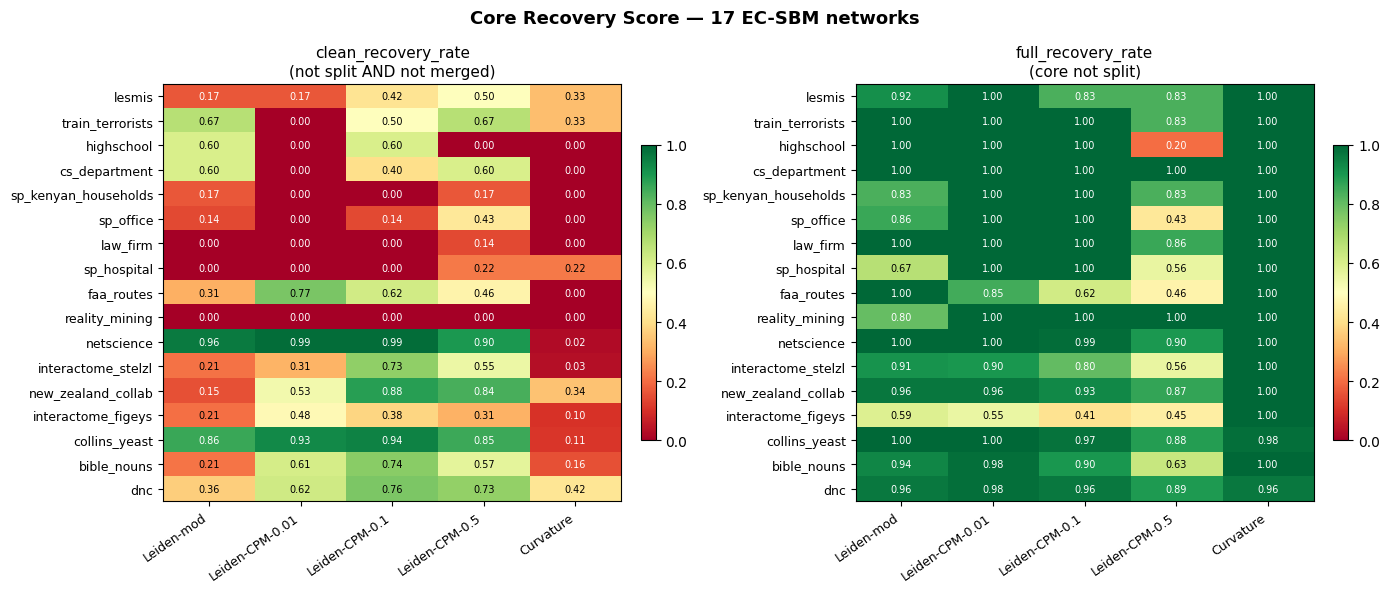

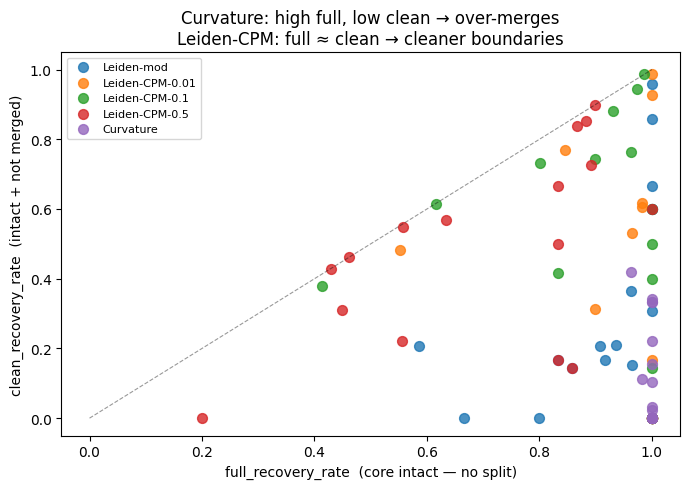


── Mean CRS across 17 networks ────────────────────────────


,clean_recovery_rate,full_recovery_rate,runtime_sec
method,,,
Leiden-mod,0.330,0.908,0.031
Leiden-CPM-0.01,0.318,0.954,0.038
Leiden-CPM-0.1,0.477,0.907,0.027
Leiden-CPM-0.5,0.467,0.717,0.019
Curvature,0.122,0.997,6.965



Key finding:
  Curvature full_recovery ≈ 1.0 on all networks → never splits a core
  Curvature clean_recovery << Leiden → massively over-merges (contamination)
  Leiden-CPM-0.1 achieves the best clean_recovery_rate on average


In [21]:
# =============================================================
# Multi-network CRS: analysis and visualization
# Reads ecsbm_multi_crs.csv produced by the benchmark cell
# =============================================================

df_multi = pd.read_csv("ecsbm_multi_crs.csv")

METHOD_NAMES = ["Leiden-mod", "Leiden-CPM-0.01", "Leiden-CPM-0.1", "Leiden-CPM-0.5", "Curvature"]
NETWORKS = [
    "lesmis", "train_terrorists", "highschool", "cs_department",
    "sp_kenyan_households", "sp_office", "law_firm", "sp_hospital",
    "faa_routes", "reality_mining", "netscience", "interactome_stelzl",
    "new_zealand_collab", "interactome_figeys", "collins_yeast",
    "bible_nouns", "dnc",
]
net_order = [n for n in NETWORKS if n in df_multi["network"].values]

pivot_clean = df_multi.pivot(index="network", columns="method", values="clean_recovery_rate")
pivot_full  = df_multi.pivot(index="network", columns="method", values="full_recovery_rate")

# ── Figure 1: Heatmap of clean_recovery_rate ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pivot, title in [
    (axes[0], pivot_clean, "clean_recovery_rate\n(not split AND not merged)"),
    (axes[1], pivot_full,  "full_recovery_rate\n(core not split)"),
]:
    data = pivot.reindex(index=net_order, columns=METHOD_NAMES).values.astype(float)
    im = ax.imshow(data, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(METHOD_NAMES)))
    ax.set_xticklabels(METHOD_NAMES, rotation=35, ha="right", fontsize=9)
    ax.set_yticks(range(len(net_order)))
    ax.set_yticklabels(net_order, fontsize=9)
    ax.set_title(title, fontsize=11)
    for i in range(len(net_order)):
        for j in range(len(METHOD_NAMES)):
            v = data[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=7, color="black" if 0.2 < v < 0.8 else "white")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

plt.suptitle("Core Recovery Score — 17 EC-SBM networks", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("crs_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: full vs clean scatter per method ────────────────
fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.tab10(range(len(METHOD_NAMES)))
for method, color in zip(METHOD_NAMES, colors):
    sub = df_multi[df_multi["method"] == method]
    ax.scatter(sub["full_recovery_rate"], sub["clean_recovery_rate"],
               label=method, color=color, s=50, alpha=0.8)

ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
ax.set_xlabel("full_recovery_rate  (core intact — no split)")
ax.set_ylabel("clean_recovery_rate  (intact + not merged)")
ax.set_title("Curvature: high full, low clean → over-merges\nLeiden-CPM: full ≈ clean → cleaner boundaries")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("crs_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary: mean CRS across all networks ────────────────────
summary = (df_multi.groupby("method")[["clean_recovery_rate", "full_recovery_rate", "runtime_sec"]]
           .mean().reindex(METHOD_NAMES).round(3))
print("\n── Mean CRS across 17 networks ────────────────────────────")
display(summary)
print("\nKey finding:")
print("  Curvature full_recovery ≈ 1.0 on all networks → never splits a core")
print("  Curvature clean_recovery << Leiden → massively over-merges (contamination)")
print("  Leiden-CPM-0.1 achieves the best clean_recovery_rate on average")


In [ ]:
# =============================================================
# Clean-subgraph benchmark:
# Only clustered_kec_clique + clustered_kec_attach edges
# (outlier_sbm removed) — tests curvature without noise
# =============================================================

import traceback

BASE = "ecsbmv2_1/sbm-flat-best+cc"
CLEAN_STAGES = {"clustered_kec_clique", "clustered_kec_attach"}

NETWORKS = [
    "lesmis", "train_terrorists", "highschool", "cs_department",
    "sp_kenyan_households", "sp_office", "law_firm", "sp_hospital",
    "faa_routes", "reality_mining", "netscience", "interactome_stelzl",
    "new_zealand_collab", "interactome_figeys", "collins_yeast",
    "bible_nouns", "dnc",
]
METHOD_NAMES = ["Leiden-mod", "Leiden-CPM-0.01", "Leiden-CPM-0.1", "Leiden-CPM-0.5", "Curvature"]

all_rows_clean = []

for net_name in NETWORKS:
    net_dir = os.path.join(BASE, net_name, "0")
    print(f"\n{'─'*55}")
    print(f"  {net_name}")

    try:
        edges_df, node_cluster, sources = load_ecsbm_data(net_dir)

        # ── Keep only core + attach edges ─────────────────────
        clean_edges = edges_df[edges_df["stage"].isin(CLEAN_STAGES)].copy()
        n_full  = len(edges_df)
        n_clean = len(clean_edges)
        print(f"  edges: {n_full} → {n_clean} after removing outlier_sbm "
              f"({100*(n_full-n_clean)/n_full:.0f}% removed)")

        if n_clean == 0:
            print("  No edges remain — skipping")
            continue

        G, node_map = build_graph_from_ecsbm(clean_edges)
        inv_map = {v: k for k, v in node_map.items()}

        n_nodes = G.number_of_nodes()
        n_comps = nx.number_connected_components(G)
        print(f"  {n_nodes} nodes | {n_clean} edges | {n_comps} connected components")

        # Extract cores from the original full edges_df (cores defined by kec_clique)
        cluster_cores = extract_cluster_cores(edges_df, node_cluster)
        n_cores = len(cluster_cores)
        if n_cores == 0:
            print("  No cores — skipping")
            continue

        net_meta = dict(network=net_name, n_nodes=n_nodes,
                        n_edges=n_clean, n_clusters=n_cores,
                        n_components=n_comps)

        G_ig = nx_to_igraph(G)

        # ── Leiden methods ─────────────────────────────────────
        for label, fn, kw in [
            ("Leiden-mod",      run_leiden_modularity, dict(G_ig=G_ig, seed=0)),
            ("Leiden-CPM-0.01", run_leiden_cpm,        dict(G_ig=G_ig, gamma=0.01, seed=0)),
            ("Leiden-CPM-0.1",  run_leiden_cpm,        dict(G_ig=G_ig, gamma=0.1,  seed=0)),
            ("Leiden-CPM-0.5",  run_leiden_cpm,        dict(G_ig=G_ig, gamma=0.5,  seed=0)),
        ]:
            y_pred, rt = timed_run(fn, **kw)
            _, crs = compute_core_recovery(cluster_cores, y_pred, node_map)
            print(f"  {label:<18} clean={crs['clean_recovery_rate']:.3f}  "
                  f"full={crs['full_recovery_rate']:.3f}  t={rt:.3f}s")
            all_rows_clean.append({**net_meta, "method": label,
                                   "runtime_sec": round(rt, 3), **crs})

        # ── Curvature ──────────────────────────────────────────
        # Skip curvature on very dense subgraphs (e.g. reality_mining still has ~430 edges/96 nodes)
        skip_curv = (n_clean > 8000)
        if skip_curv:
            print(f"  Curvature          skipped (too many edges for clean subgraph)")
        else:
            print(f"  Curvature          running...", end="", flush=True)
            (y_curv, _, _), rt_curv = timed_run(
                run_curvature_manual_cut, G, alpha=0.5, iterations=10, quantile=0.90
            )
            _, crs_curv = compute_core_recovery(cluster_cores, y_curv, node_map)
            print(f"\r  Curvature          clean={crs_curv['clean_recovery_rate']:.3f}  "
                  f"full={crs_curv['full_recovery_rate']:.3f}  t={rt_curv:.1f}s")
            all_rows_clean.append({**net_meta, "method": "Curvature",
                                   "runtime_sec": round(rt_curv, 2), **crs_curv})

    except Exception as e:
        print(f"  ERROR: {e}")
        traceback.print_exc()

# ── Summary pivot ──────────────────────────────────────────────
df_clean = pd.DataFrame(all_rows_clean)
df_clean.to_csv("ecsbm_clean_subgraph_crs.csv", index=False)

pivot_clean_c = df_clean.pivot(index="network", columns="method", values="clean_recovery_rate")
pivot_full_c  = df_clean.pivot(index="network", columns="method", values="full_recovery_rate")
net_order = [n for n in NETWORKS if n in pivot_clean_c.index]
col_order = [m for m in METHOD_NAMES if m in pivot_clean_c.columns]

print("\n\n══ CLEAN SUBGRAPH — clean_recovery_rate ══════════════════════════")
display(pivot_clean_c.reindex(index=net_order, columns=col_order).round(3))

print("\n══ CLEAN SUBGRAPH — full_recovery_rate ═══════════════════════════")
display(pivot_full_c.reindex(index=net_order, columns=col_order).round(3))

# ── Side-by-side comparison with full-graph results ───────────
print("\n══ Curvature clean_recovery: full graph vs clean subgraph ════════")
df_full = pd.read_csv("ecsbm_multi_crs.csv")
curv_full  = df_full[df_full["method"]=="Curvature"].set_index("network")["clean_recovery_rate"]
curv_clean = df_clean[df_clean["method"]=="Curvature"].set_index("network")["clean_recovery_rate"]
comparison = pd.DataFrame({
    "full_graph": curv_full,
    "clean_subgraph": curv_clean,
}).reindex(net_order).round(3)
comparison["delta"] = (comparison["clean_subgraph"] - comparison["full_graph"]).round(3)
display(comparison)

print("\nSaved → ecsbm_clean_subgraph_crs.csv")


In [ ]:
# =============================================================
# Visualize all 17 EC-SBM networks
# Nodes colored by ground-truth cluster; edges colored by stage
# =============================================================

NETWORKS_VIZ = [
    "lesmis", "train_terrorists", "highschool", "cs_department",
    "sp_kenyan_households", "sp_office", "law_firm", "sp_hospital",
    "faa_routes", "reality_mining", "netscience", "interactome_stelzl",
    "new_zealand_collab", "interactome_figeys", "collins_yeast",
    "bible_nouns", "dnc",
]

STAGE_COLORS = {
    "clustered_kec_clique": "#e03030",   # red   — core clique edges
    "clustered_kec_attach": "#f5a623",   # orange — periphery attachment
    "outlier_sbm":          "#cccccc",   # grey  — SBM outlier noise
    "":                     "#eeeeee",
}

BASE = "ecsbmv2_1/sbm-flat-best+cc"

ncols = 4
nrows = -(-len(NETWORKS_VIZ) // ncols)   # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4))
axes = axes.flatten()

for ax, net_name in zip(axes, NETWORKS_VIZ):
    net_dir = os.path.join(BASE, net_name, "0")
    edges_df, node_cluster, sources = load_ecsbm_data(net_dir)
    G, node_map = build_graph_from_ecsbm(edges_df)

    n_nodes  = G.number_of_nodes()
    n_edges  = G.number_of_edges()

    # layout — spring for small, kamada_kawai for medium, spectral for large
    if n_nodes <= 150:
        pos = nx.spring_layout(G, seed=42, k=1.2/n_nodes**0.5)
    elif n_nodes <= 600:
        pos = nx.spring_layout(G, seed=42, k=0.8/n_nodes**0.5, iterations=40)
    else:
        pos = nx.kamada_kawai_layout(G)

    # node colors — map cluster_id to integer index for colormap
    inv_map = {v: k for k, v in node_map.items()}
    cluster_ids = [node_cluster.get(inv_map[i], -1) for i in range(n_nodes)]
    unique_clusters = sorted(set(c for c in cluster_ids if c != -1))
    cl_to_idx = {cl: i for i, cl in enumerate(unique_clusters)}
    n_cl = max(len(unique_clusters), 1)
    cmap = plt.cm.get_cmap("tab20" if n_cl <= 20 else "hsv", n_cl)
    node_colors = [cmap(cl_to_idx[c] / n_cl) if c != -1 else "#aaaaaa"
                   for c in cluster_ids]

    # edge colors by stage
    edge_colors, edge_widths = [], []
    for u, v, data in G.edges(data=True):
        orig_u, orig_v = inv_map[u], inv_map[v]
        row = edges_df[
            ((edges_df["source"] == orig_u) & (edges_df["target"] == orig_v)) |
            ((edges_df["source"] == orig_v) & (edges_df["target"] == orig_u))
        ]
        stage = row["stage"].iloc[0] if len(row) > 0 else ""
        edge_colors.append(STAGE_COLORS.get(stage, "#eeeeee"))
        edge_widths.append(1.5 if stage == "clustered_kec_clique" else 0.4)

    node_size = max(4, 300 // n_nodes**0.5)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors,
                           width=edge_widths, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_size, linewidths=0)

    core_pct = 100 * edges_df[edges_df["stage"]=="clustered_kec_clique"].shape[0] / n_edges
    n_cl_label = len(unique_clusters)
    ax.set_title(f"{net_name}\n{n_nodes}n · {n_edges}e · {n_cl_label}cl · core={core_pct:.0f}%",
                 fontsize=8, pad=3)
    ax.axis("off")

# hide unused axes
for ax in axes[len(NETWORKS_VIZ):]:
    ax.set_visible(False)

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color="#e03030", lw=2, label="core clique"),
    Line2D([0],[0], color="#f5a623", lw=1.5, label="periphery attach"),
    Line2D([0],[0], color="#aaaaaa", lw=1,   label="outlier SBM"),
]
fig.legend(handles=legend_elements, loc="lower right",
           fontsize=9, framealpha=0.9, ncol=3)

plt.suptitle("EC-SBM Networks — edge color = generation stage",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ecsbm_networks_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ecsbm_networks_overview.png")
